# 03 — Interpretasi Cluster & Insight Kebijakan
Profil tiap segmen, anggota, dan rekomendasi kebijakan stabilisasi harga pangan.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", None)

In [2]:
import joblib
df = pd.read_csv(ROOT / "data" / "processed" / "hasil_clustering.csv")
meta = joblib.load(ROOT / "models" / "meta.pkl")
kmeans = joblib.load(ROOT / "models" / "kmeans_model.pkl")
scaler = joblib.load(ROOT / "models" / "scaler.pkl")
FEATURES = meta["features"]
df[["Provinsi", "KV_mean", "CPPD_Ton", "Cluster", "Segmen"]]

,Provinsi,KV_mean,CPPD_Ton,Cluster,Segmen
0,Aceh,5.289992,187.463636,1,Zona Mandiri & Stabil
1,Bali,5.807111,390.380000,1,Zona Mandiri & Stabil
2,Banten,5.555611,443.520000,1,Zona Mandiri & Stabil
3,Bengkulu,9.666911,63.104545,0,Zona Rentan Fluktuatif
4,DI Yogyakarta,7.536645,305.300000,0,Zona Rentan Fluktuatif
5,Gorontalo,8.622247,8.154545,0,Zona Rentan Fluktuatif
6,Jambi,5.460527,66.140000,1,Zona Mandiri & Stabil
7,Jawa Barat,5.941759,2152.091818,2,Zona Hub Logistik (Surplus CPPD)
8,Jawa Tengah,6.640810,102.583636,1,Zona Mandiri & Stabil
9,Jawa Timur,7.705602,449.430000,0,Zona Rentan Fluktuatif


## 1. Profil Statistik per Segmen

In [3]:
profil = df.groupby("Segmen").agg(
    Jumlah_Provinsi=("Provinsi", "count"),
    KV_2022=("KV_2022", "mean"), KV_2023=("KV_2023", "mean"),
    KV_2024=("KV_2024", "mean"), KV_mean=("KV_mean", "mean"),
    CPPD_Ton=("CPPD_Ton", "mean"),
).round(2)
profil

,Jumlah_Provinsi,KV_2022,KV_2023,KV_2024,KV_mean,CPPD_Ton
Segmen,,,,,,
Zona Hub Logistik (Surplus CPPD),1,9.15,4.17,4.51,5.94,2152.09
Zona Mandiri & Stabil,17,8.67,3.40,4.25,5.44,155.52
Zona Rentan Fluktuatif,7,11.27,5.86,8.91,8.68,195.90


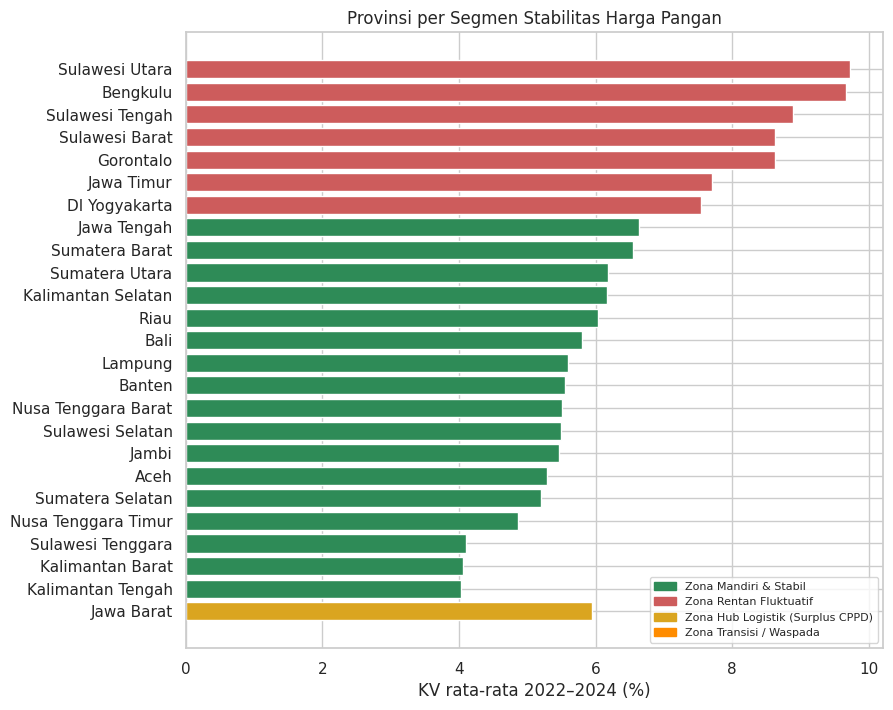

In [4]:
seg_colors = {"Zona Mandiri & Stabil": "seagreen",
              "Zona Rentan Fluktuatif": "indianred",
              "Zona Hub Logistik (Surplus CPPD)": "goldenrod",
              "Zona Transisi / Waspada": "darkorange"}
d = df.sort_values(["Segmen", "KV_mean"])
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(d["Provinsi"], d["KV_mean"], color=[seg_colors.get(s, "gray") for s in d["Segmen"]])
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in seg_colors.values()]
ax.legend(handles, seg_colors.keys(), fontsize=8, loc="lower right")
ax.set_xlabel("KV rata-rata 2022–2024 (%)")
ax.set_title("Provinsi per Segmen Stabilitas Harga Pangan")
fig.savefig(FIG / "interpretasi_segmen_provinsi.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Anggota Tiap Segmen

In [5]:
for seg, grp in df.groupby("Segmen"):
    print(f"\n=== {seg} ({len(grp)} provinsi) ===")
    print(", ".join(grp["Provinsi"]))


=== Zona Hub Logistik (Surplus CPPD) (1 provinsi) ===
Jawa Barat

=== Zona Mandiri & Stabil (17 provinsi) ===
Aceh, Bali, Banten, Jambi, Jawa Tengah, Kalimantan Barat, Kalimantan Selatan, Kalimantan Tengah, Lampung, Nusa Tenggara Barat, Nusa Tenggara Timur, Riau, Sulawesi Selatan, Sulawesi Tenggara, Sumatera Barat, Sumatera Selatan, Sumatera Utara

=== Zona Rentan Fluktuatif (7 provinsi) ===
Bengkulu, DI Yogyakarta, Gorontalo, Jawa Timur, Sulawesi Barat, Sulawesi Tengah, Sulawesi Utara


## 3. Karakteristik & Rekomendasi Kebijakan

| Segmen | Karakteristik | Strategi Intervensi |
|---|---|---|
| **Zona Rentan Fluktuatif** | KV tinggi lintas tahun, cadangan pangan umumnya kecil | Operasi pasar darurat, percepatan distribusi logistik dari pusat, subsidi silang antar provinsi |
| **Zona Mandiri & Stabil** | KV rendah dan konsisten | Optimalisasi buffer stock, dijadikan penyokong zona rentan |
| **Zona Hub Logistik (Surplus CPPD)** | CPPD ekstrem (Jawa Barat ~2.152 ton), KV moderat | Ditetapkan sebagai hub distribusi nasional; salurkan surplus CPPD ke zona rentan terdekat |

## 4. Catatan Metodologis & Limitasi 
1. **Deviasi dari proposal:** fitur Sertifikat JKP dibatalkan karena datanya hanya level nasional — didokumentasikan sebagai limitasi data, bukan disembunyikan.
2. **Hipotesis proposal tidak terbukti:** korelasi CPPD vs KV ≈ −0.04. Besaran stok bukan penentu tunggal stabilitas harga; kebijakan perlu memperhatikan distribusi, bukan hanya akumulasi stok.
3. **Silhouette 0.41 < target 0.5:** wajar untuk data sosial-ekonomi; alternatif DBSCAN mencapai 0.64 tetapi membuang ~44% provinsi sebagai noise — tidak layak untuk kebijakan yang harus mencakup semua provinsi.
4. **Cakupan 25 provinsi** (bukan 38): dibatasi cakupan data KV produsen; provinsi pemekaran Papua dan beberapa lainnya belum tersedia di panel harga produsen.
5. Cluster hub beranggota tunggal (Jawa Barat) mencerminkan realita outlier CPPD, bukan kegagalan model — dipertahankan karena bermakna kebijakan.

## 5. Kesimpulan
K-Means (K=3, silhouette 0.41, DBI 0.76) berhasil memetakan 25 provinsi ke 3 segmen stabilitas harga pangan yang dapat ditindaklanjuti: mayoritas provinsi stabil, sekelompok provinsi rentan fluktuatif yang perlu intervensi logistik prioritas, dan Jawa Barat sebagai hub surplus cadangan pangan nasional.